K_plus offdiag H[0,1] = (kx + i ky) * a * t = (-0.314159142+0.544139676j)
K_minus offdiag H[0,1] = (-kx + i ky) * a * t = (0.314159142+0.544139676j)
Conjugate check K_plus: (-0.314159142-0.544139676j) == (-0.314159142-0.544139676j)
Conjugate check K_minus: (0.314159142-0.544139676j) == (0.314159142-0.544139676j)
K_plus Hermitian? True
K_minus Hermitian? True

arg(Hp[i,j]) ~ -Δφ mod 2π: -2.094395038417861  vs  4.188790268761726
K_plus eigenvalues (eV): [1.935413 1.935413 2.279932]
K_plus strengths (|D_S|^2): [4.806936 4.806937 0.      ]
K_minus strengths (|D_S|^2): [0.066058 0.066058 0.      ]
Count K_plus = 3
Count K_minus = 3


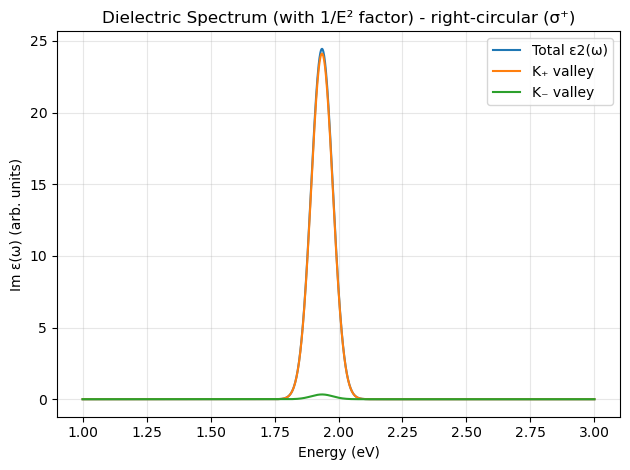

In [ ]:
import time as tm
import matplotlib.pyplot as plt
import matplotlib.dates  as dates
import numpy as np
import json
import math
from K_P_dirac import build_two_valley_dirac_series
from BSE_hamiltonian import build_bse_two_valleys_from_series, coulomb_rpa_kernel_flexible, phi_angles_two_valleys
from dielectric_function import compute_dielectric_for_two_valleys, plot_dielectric


if __name__ == "__main__":

    # 1. Load settings from JSON file
    #settings_file = "parameters.json"  # path to the input settings
   # with open(settings_file, "r") as f:
        #settings = json.load(f)

    ##source_type = settings.get("source_type", "").lower()
    ##file_path = settings.get("band_file", "")
    ##do_optics = settings.get("do_optics", False)
##
##
    ##abs_freq_fac_switch = parameters["Abs_plotting"]['abs_freq_fac_switch']
    ##step = parameters["Abs_plotting"]['step']
    ##step_width = parameters["Abs_plotting"]['step_width']
    ##le_sigma = parameters["Abs_plotting"]['le_sigma']


    ###The most important arrays and parameters!!!


    param_list = [
        (-0.81, 0.81,  1.325567,  0.000000),
        (-0.81, 0.81, -0.662783,  1.147974),
        (-0.81, 0.81, -0.662783, -1.147974),
    ]
    a = 3.16   # e.g., Å (if k in Å^-1)
    t = 0.15   # eV (example scale)
    series = build_two_valley_dirac_series(param_list, a=a, t=t)

    # Inspect first entry of each valley
    Kp0 = series["K_plus"].items[1]
    Km0 = series["K_minus"].items[1]
    print("K_plus offdiag H[0,1] = (kx + i ky) * a * t =", Kp0.H[0,1])
    print("K_minus offdiag H[0,1] = (-kx + i ky) * a * t =", Km0.H[0,1])
    print("Conjugate check K_plus:", Kp0.H[1,0], "==", np.conjugate(Kp0.H[0,1]))
    print("Conjugate check K_minus:", Km0.H[1,0], "==", np.conjugate(Km0.H[0,1]))
    #Diagonalization and get the eigenvalue with eigenvetors
   
   # Use χ given in Å^-1 by default (chi_is_inverse_default=True)
    out = build_bse_two_valleys_from_series(series)

    Hp, Hm = out["K_plus"].H_BSE, out["K_minus"].H_BSE
    # Hermiticity
    print("K_plus Hermitian?",  np.allclose(Hp, Hp.conj().T))
    print("K_minus Hermitian?", np.allclose(Hm, Hm.conj().T))
    print("")
    # Phase factor check for one pair (i<j)
    i, j = 0, 2
    # recompute Δφ quickly
    phi_plus, _ = phi_angles_two_valleys(series)
    dphi = phi_plus[i] - phi_plus[j]
    print("arg(Hp[i,j]) ~ -Δφ mod 2π:", np.angle(Hp[i,j]), " vs ", (-dphi) % (2*np.pi))
 
    # --- compute dielectric spectrum (includes 1/E^2 frequency factor) ---
    polarization = "left"  # "left" or "right"
    res = compute_dielectric_for_two_valleys(
        series,
        polarization=polarization,
        eta=0.05,
        omega_min=1.0, omega_max=3.0, omega_points=1200,
        prefactor=1.0,
        
    )

    np.set_printoptions(precision=6, suppress=True)
    print("K_plus eigenvalues (eV):", res.eigvals_K_plus)
    print("K_plus strengths (|D_S|^2):", res.exc_strengths_K_plus)
    print("K_minus strengths (|D_S|^2):", res.exc_strengths_K_minus)

    print("Count K_plus =", res.exc_strengths_K_plus.size)
    print("Count K_minus =", res.exc_strengths_K_minus.size)

    # (optional) consistency checks: strengths length should match number of eigenstates
    assert res.exc_strengths_K_plus.shape  == res.eigvals_K_plus.shape
    assert res.exc_strengths_K_minus.shape == res.eigvals_K_minus.shape
    label_map = {"left": "left-circular (σ⁻)", "right": "right-circular (σ⁺)"}
    pol_label = label_map.get(polarization.lower(), polarization)

    # --- plot: ε2(ω) vs energy ω (eV) ---
    fig, ax = plt.subplots()
    ax.plot(res.omega, res.eps2_total, label="Total ε2(ω)")
    ax.plot(res.omega, res.eps2_K_plus, label="K₊ valley")
    ax.plot(res.omega, res.eps2_K_minus, label="K₋ valley")

    ax.set_xlabel("Energy (eV)")
    ax.set_ylabel("Im ε(ω) (arb. units)")
    ax.set_title("Dielectric Spectrum (with 1/E² factor) - {pol_label}".format(pol_label=pol_label))
    ax.legend()
    ax.grid(True, alpha=0.3)
    fig.tight_layout()
    plt.show()



